**Downloading Dataset**

In [1]:
!pip install kaggle

import os

os.environ['KAGGLE_CONFIG_DIR'] = "/content"

!kaggle datasets download -d aadityasinghal/facial-expression-dataset

import zipfile

# If the dataset is in a zip file
with zipfile.ZipFile("facial-expression-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("facial-expression-dataset")

import os

dataset_path = "/content/facial-expression-dataset"
print(os.listdir(dataset_path))

Dataset URL: https://www.kaggle.com/datasets/aadityasinghal/facial-expression-dataset
License(s): DbCL-1.0
100% 60.7M/60.7M [00:00<00:00, 75.8MB/s]

['test', 'train']


In [2]:
!pip install tensorflow

In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')
%matplotlib inline
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from keras.preprocessing.image import load_img
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D

**Load The DataSet**

In [4]:
TRAIN_DIR = '/content/facial-expression-dataset/train/train'
TEST_DIR = '/content/facial-expression-dataset/test/test'

In [5]:
def load_dataset(directory):
  image_paths = []
  labels = []
  for label in os.listdir(directory):
    for filename in os.listdir(os.path.join(directory, label)): # Use os.path.join to create the correct path
      image_path = os.path.join(directory, label, filename)
      image_paths.append(image_path)
      labels.append(label)
    print(label, "Completed")
  return image_paths, labels

In [6]:
## convert into dataframe
train = pd.DataFrame()
train['image'], train ['label'] = load_dataset(TRAIN_DIR)
# shuffle the dataset
train = train.sample(frac=1).reset_index(drop=True)
train.head()

happy Completed
fear Completed
angry Completed
disgust Completed
sad Completed
neutral Completed
surprise Completed


,image,label
0,/content/facial-expression-dataset/train/train...,surprise
1,/content/facial-expression-dataset/train/train...,surprise
2,/content/facial-expression-dataset/train/train...,happy
3,/content/facial-expression-dataset/train/train...,neutral
4,/content/facial-expression-dataset/train/train...,fear


In [7]:
def load_dataset(directory):
  image_paths = []
  labels = []
  for label in os.listdir(directory):
    for filename in os.listdir(os.path.join(directory, label)): # Use os.path.join to create the correct path
      image_path = os.path.join(directory, label, filename)
      image_paths.append(image_path)
      labels.append(label)
    print(label, "Completed")
  return image_paths, labels

In [8]:
test = pd.DataFrame()
test['image'], test ['label'] = load_dataset(TEST_DIR)
test.head()

happy Completed
fear Completed
angry Completed
disgust Completed
sad Completed
neutral Completed
surprise Completed


,image,label
0,/content/facial-expression-dataset/test/test/h...,happy
1,/content/facial-expression-dataset/test/test/h...,happy
2,/content/facial-expression-dataset/test/test/h...,happy
3,/content/facial-expression-dataset/test/test/h...,happy
4,/content/facial-expression-dataset/test/test/h...,happy


**Exploratory Data Analysis**

<Axes: xlabel='count', ylabel='label'>

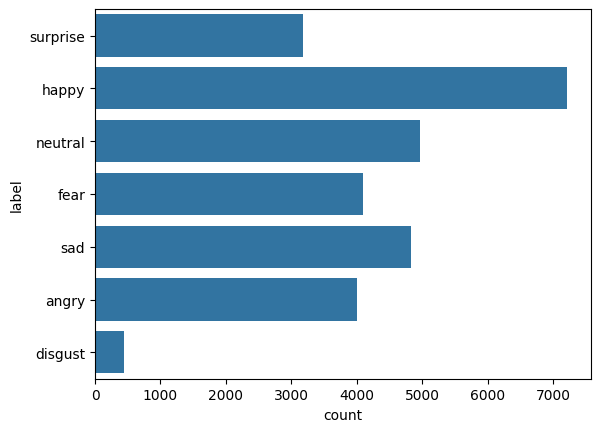

In [9]:
sns.countplot(train['label'])

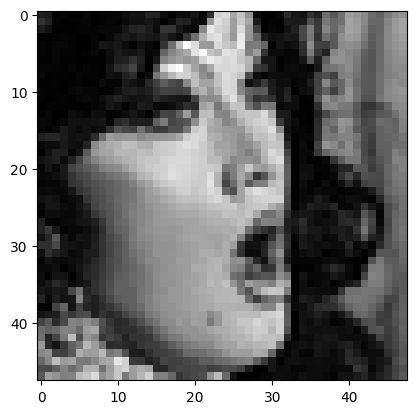

In [10]:
from PIL import Image
img = Image.open(train['image'][0])
plt.imshow(img, cmap='gray')

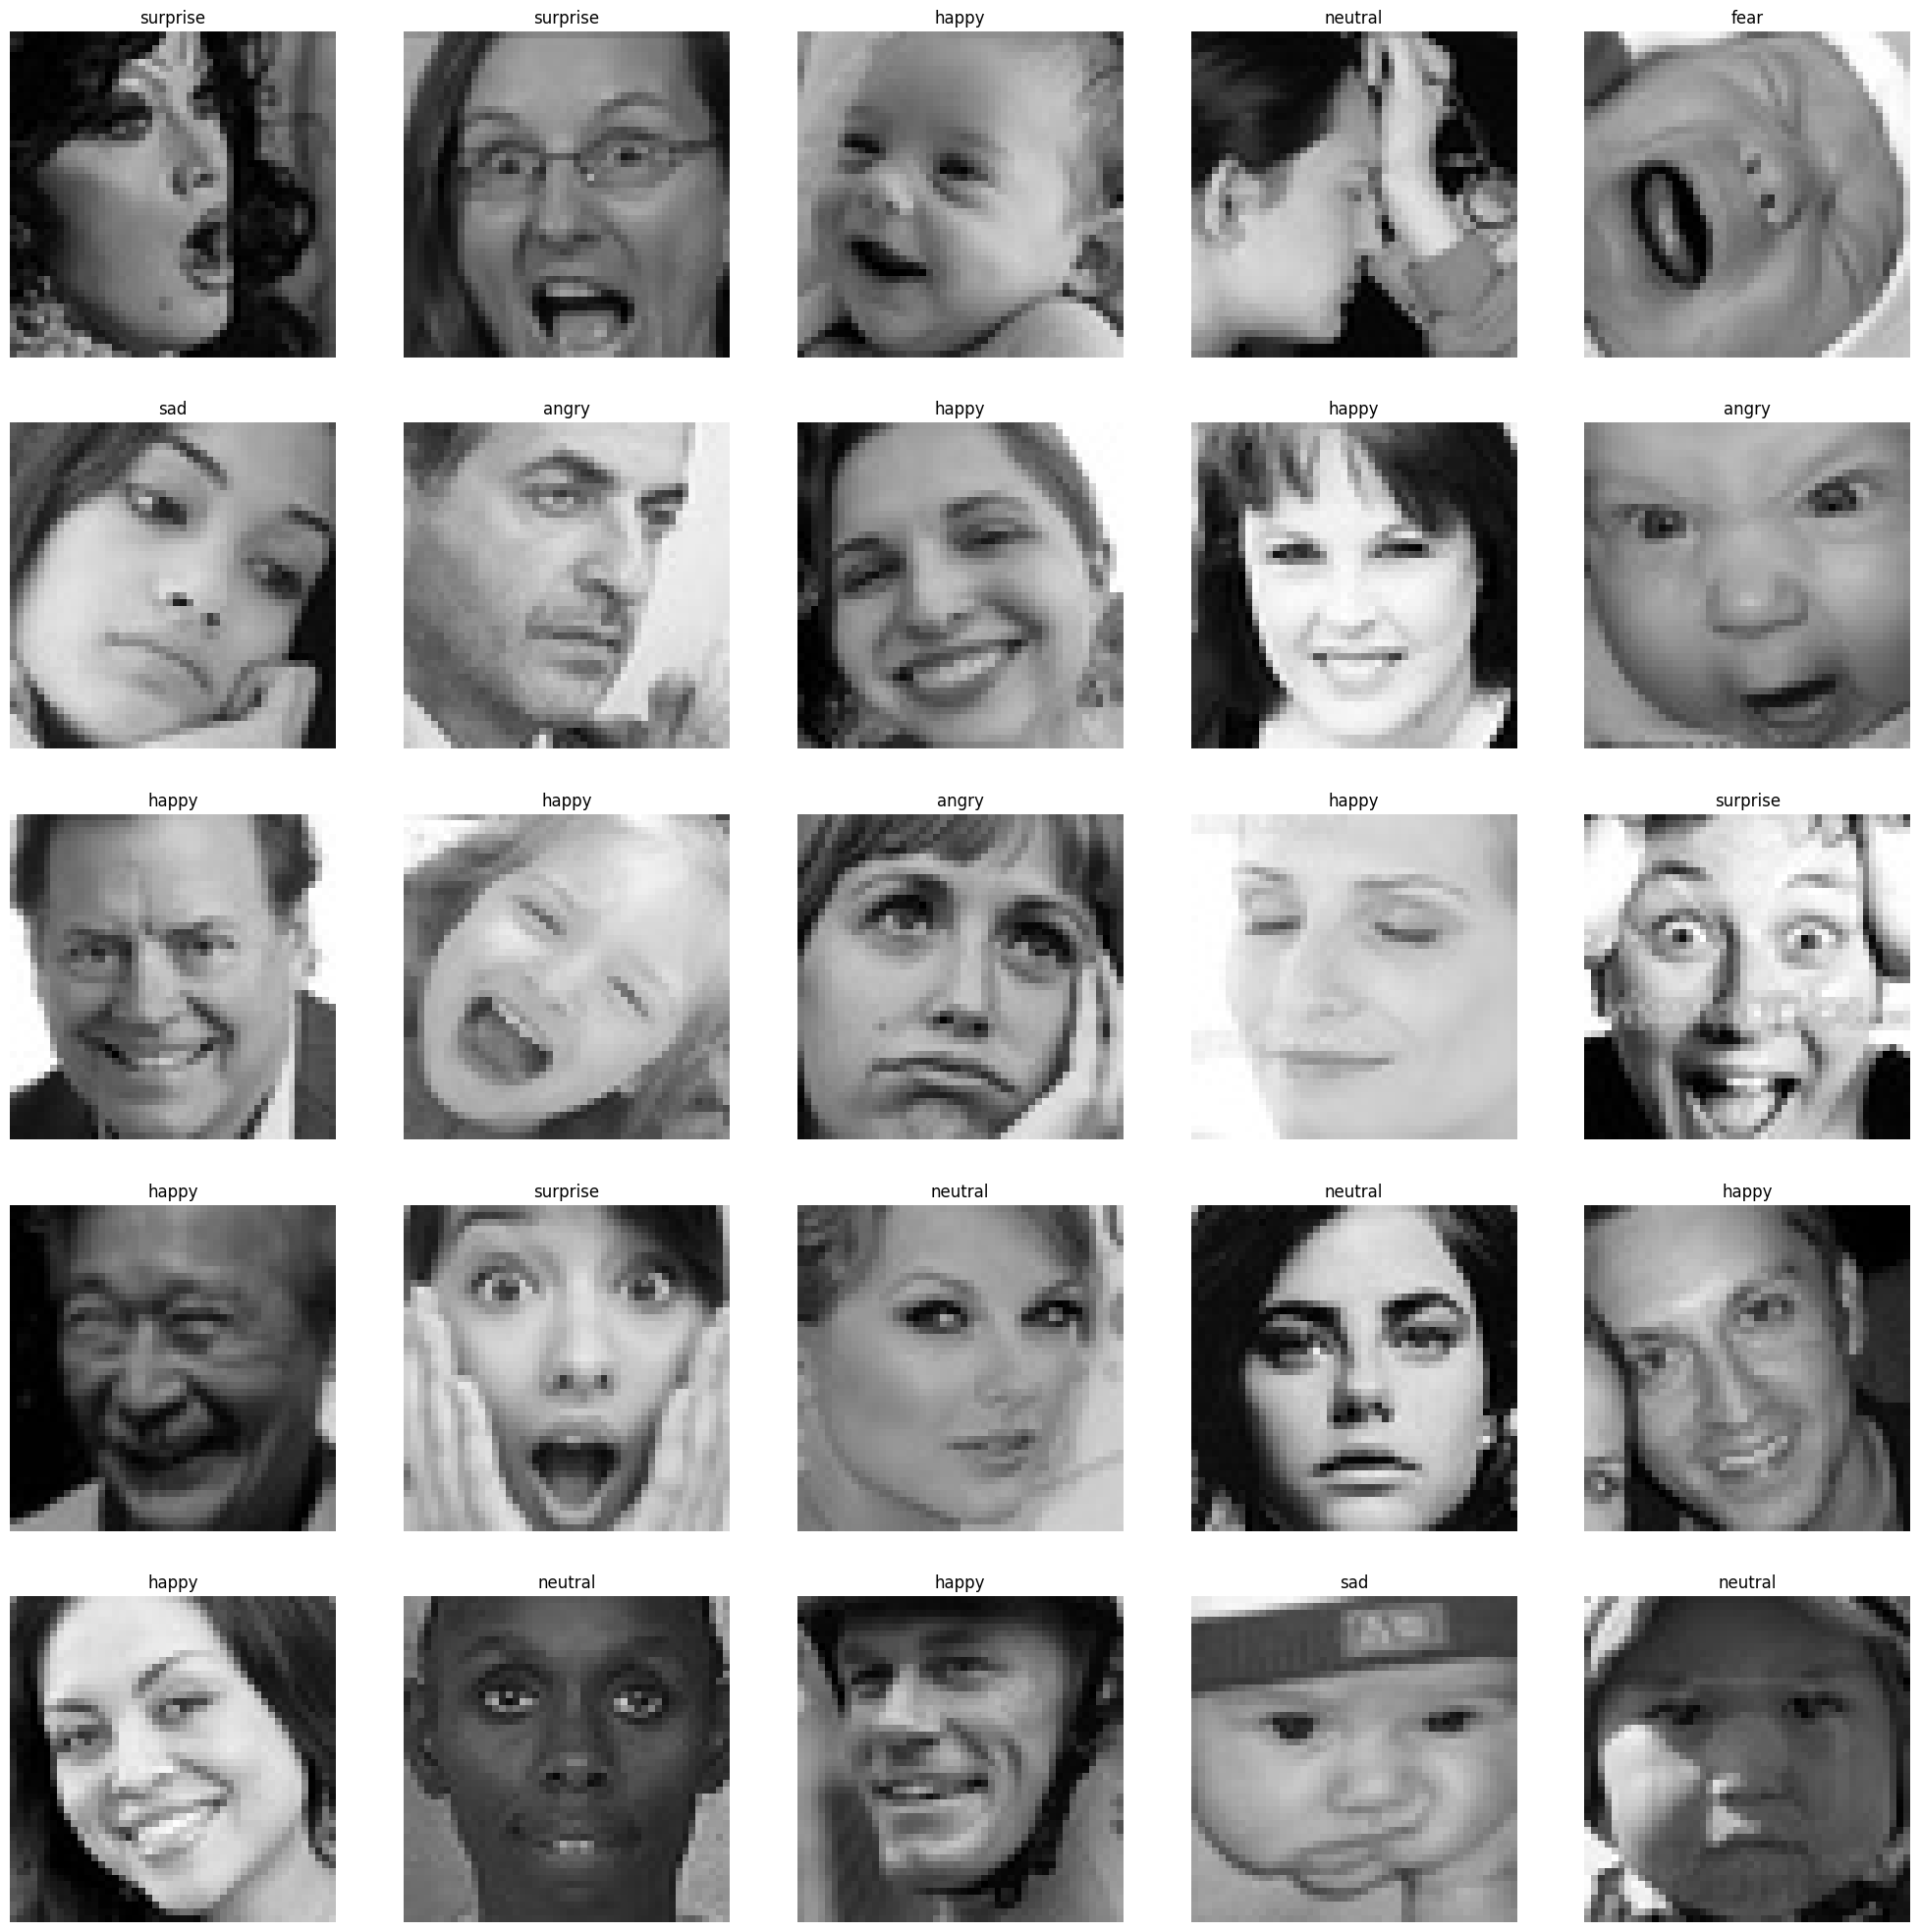

In [11]:
#to display grid of images
plt.figure(figsize=(25,25))
files = train.iloc[0:25]
for index, file, label in files.itertuples():
  plt.subplot(5, 5, index+1)
  img = load_img(file)
  img = np.array(img)
  plt.imshow(img)
  plt.title(label)
  plt.axis('off')

**Feature Extraction**

In [12]:
def extract_features(images):
  features = []
  for image in tqdm(images):
    # Use color_mode='grayscale' instead of grayscale=True
    img = load_img(image, color_mode='grayscale')
    img= np.array(img)
    features.append(img)
  features = np.array(features)
  features = features.reshape(len(features), 48, 48, 1)
  return features

In [13]:
train_features = extract_features(train['image'])

  0%|          | 0/28709 [00:00<?, ?it/s]

In [14]:
test_features = extract_features(test['image'])

  0%|          | 0/7178 [00:00<?, ?it/s]

In [15]:
## normalize the image
x_train = train_features/255.0
x_test = test_features/255.0

In [16]:
## convert label to integer
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(train['label'])
label_mapping = dict(zip(le.transform(le.classes_), le.classes_))
print(label_mapping)
print(train[['image', 'label']].head())

# For test dataset
print(test[['image', 'label']].head())

{np.int64(0): 'angry', np.int64(1): 'disgust', np.int64(2): 'fear', np.int64(3): 'happy', np.int64(4): 'neutral', np.int64(5): 'sad', np.int64(6): 'surprise'}
                                               image     label
0  /content/facial-expression-dataset/train/train...  surprise
1  /content/facial-expression-dataset/train/train...  surprise
2  /content/facial-expression-dataset/train/train...     happy
3  /content/facial-expression-dataset/train/train...   neutral
4  /content/facial-expression-dataset/train/train...      fear
                                               image  label
0  /content/facial-expression-dataset/test/test/h...  happy
1  /content/facial-expression-dataset/test/test/h...  happy
2  /content/facial-expression-dataset/test/test/h...  happy
3  /content/facial-expression-dataset/test/test/h...  happy
4  /content/facial-expression-dataset/test/test/h...  happy


In [17]:
y_train = le.transform(train['label'])
y_test = le.transform(test['label'])

In [18]:
emotion_label = le.inverse_transform([np.argmax(y_train[0])])
print(emotion_label)

['angry']


In [19]:
y_train = to_categorical(y_train, num_classes=7)
y_test = to_categorical(y_test, num_classes=7)

In [20]:
y_train[0]

array([0., 0., 0., 0., 0., 0., 1.])

In [21]:
# config input_shape
input_shape = (48, 48, 1)
output_class = 7

**Model Creation**

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)))
model.add(MaxPooling2D(2,2))
model.add(BatchNormalization())

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(BatchNormalization())

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(BatchNormalization())

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(7, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [24]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 109s 225ms/step - accuracy: 0.3816 - loss: 1.6549 - val_accuracy: 0.3396 - val_loss: 1.6682
Epoch 2/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 137s 215ms/step - accuracy: 0.4944 - loss: 1.3350 - val_accuracy: 0.4691 - val_loss: 1.3675
Epoch 3/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 142s 216ms/step - accuracy: 0.5502 - loss: 1.1906 - val_accuracy: 0.5070 - val_loss: 1.2913
Epoch 4/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 143s 220ms/step - accuracy: 0.5945 - loss: 1.0836 - val_accuracy: 0.5389 - val_loss: 1.2285
Epoch 5/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 98s 218ms/step - accuracy: 0.6336 - loss: 0.9764 - val_accuracy: 0.5538 - val_loss: 1.2162
Epoch 6/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 142s 219ms/step - accuracy: 0.6769 - loss: 0.8695 - val_accuracy: 0.5456 - val_loss: 1.2400
Epoch 7/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 97s 217ms/step - accuracy: 0.7163 - loss: 0.7643 - val_accuracy: 0.5301 - val_loss: 1.3303
Epoch 8/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 142s 217ms/step - accuracy: 0.7517 - l

**Plot the Results**

225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step
Confusion Matrix:
[[ 496    3  132   78  135   91   23]
 [  52   33   13    6    2    4    1]
 [ 163    3  388   77  154  150   89]
 [  76    2   79 1421  108   52   36]
 [ 150    4  122  145  681  106   25]
 [ 210    1  184  130  302  397   23]
 [  34    0  131   50   43   14  559]]


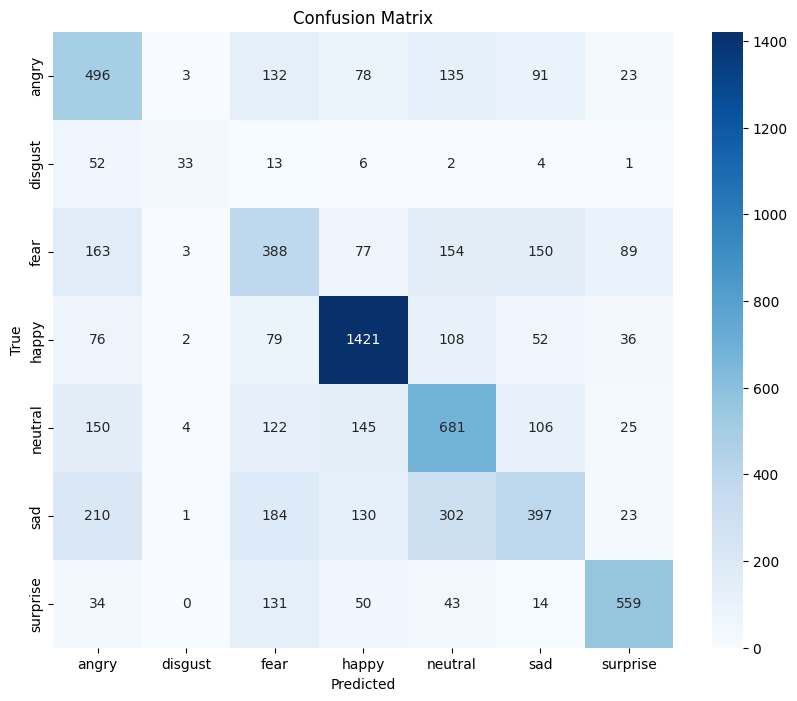

In [26]:
from sklearn.metrics import confusion_matrix


y_pred = model.predict(x_test)

# Convert predictions from one-hot encoding to labels
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)


# Confusion Matrix
conf_matrix = confusion_matrix(y_true_labels, y_pred_labels)
print("Confusion Matrix:")
print(conf_matrix)

# Visualize Confusion Matrix with Seaborn heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

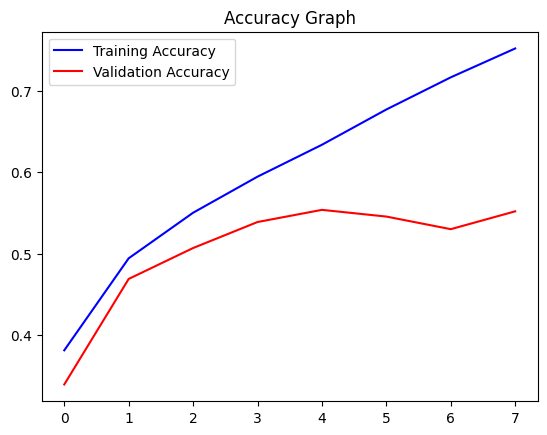

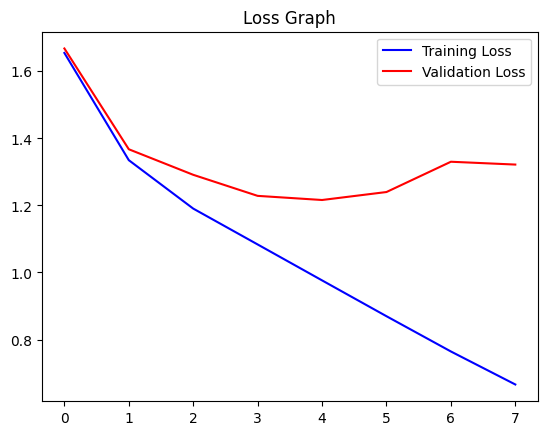

In [27]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))
plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.figure()

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(acc))
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title("Loss Graph")
plt.legend()

plt.show()

Original Output: happy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted Output: happy


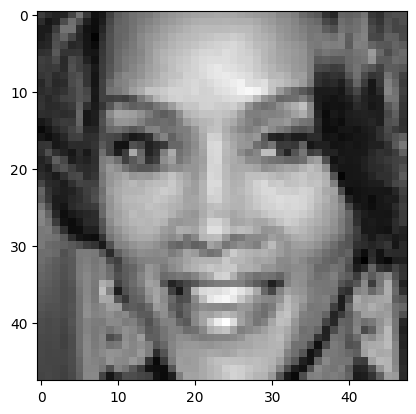

In [28]:
import random
image_index = random.randint(0, len(test))
print("Original Output:", test['label'][image_index])
pred = model.predict(x_test[image_index].reshape(1, 48, 48, 1))
prediction_label= le.inverse_transform([pred.argmax()])[0]
print("Predicted Output:", prediction_label)
plt.imshow(x_test[image_index].reshape(48, 48), cmap='gray')

**Saving the Model**

In [31]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [33]:
model.save('/content/drive/MyDrive/facial_expression_model.h5')